In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [59]:
df["Дата"] = pd.to_datetime(df["Дата"])

Сгруппируйте данные по дате, посчитайте количество продаж

In [60]:
grouped_df = df.groupby("Дата").size().reset_index(name = "Количество продаж")

Вывести несколько первых строк сгруппированных данных

In [61]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


Нарисуйте график продаж у `grouped_df`

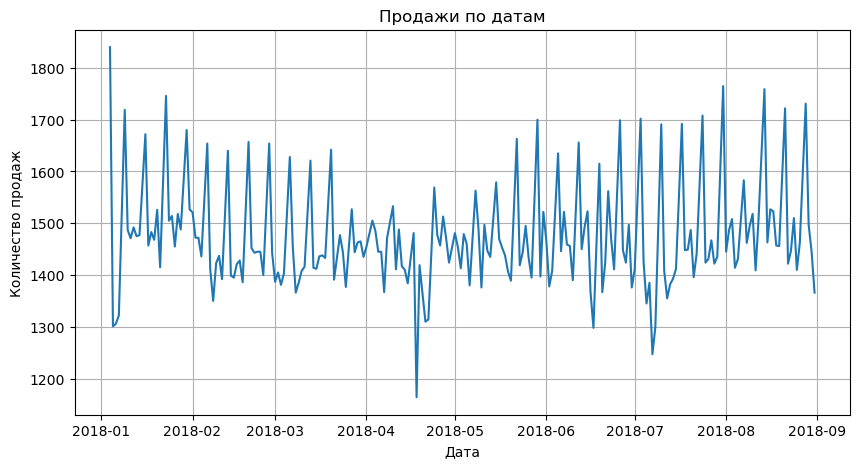

In [62]:
plt.figure(figsize = (10, 5))
plt.plot(grouped_df["Дата"], grouped_df["Количество продаж"])
plt.title("Продажи по датам")
plt.xlabel("Дата")
plt.ylabel("Количество продаж")
plt.grid()

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике показано изменение количества продаж по датам. Сразу можно увидеть, что продажи сильно скачат. Эти значения постоянно то увеличиваются, 
то резко снижаются. Все это выглядит нестабильным и напоминает пульс, так как между днями, неделями наблюдаются заметные различия. И нет такого, 
чтобы график постоянно возрастал или, наоборот, убывал на протяжении данного периода времени. 
Продажи находятся примерно на одном уровне, но внутри каждого месяца происходят частые скачки. Я предпологаю, что такие колебания связаны с 
различиями между рабочими и выходными (праздничными) днями, изменением спроса или несезонность продаваемого товара. Также хочу отметить снижение продаж 
с конца марта по середину мая, где, визуально, нет больших продаж. 
В целом, продажи носят нестабильный характер с выраженными краткосрочными колебаниями.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [63]:
df["Количество"].max()

200

In [64]:
df.loc[df["Количество"].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [65]:
# Здесь вы же просили за июнь, июль, август вместе? Или отдельно за каждый месяц? Я взял первый вариант:

In [66]:
df["Месяц"] = df["Дата"].dt.month
df["День_недели"] = df["Дата"].dt.day_name()

summer_df = df[df["Месяц"].isin([6, 7, 8])]

In [67]:
wednesday_df = summer_df[summer_df["День_недели"] == "Wednesday"]

warehouse3_df = wednesday_df[wednesday_df["Склад"] == 3]

In [68]:
top_product = (
    warehouse3_df
    .groupby("Номенклатура")["Количество"]
    .sum()
    .sort_values(ascending = False)
    .head(1)
)

top_product

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [69]:
weather = pd.read_csv("Погода2018.csv", sep = ";", encoding = "cp1251")

In [70]:
weather.head()

,Местное время в Астане,T
0,30.09.2018 23:00,"9,9"
1,30.09.2018 20:00,"11,9"
2,30.09.2018 17:00,"19,1"
3,30.09.2018 14:00,"19,7"
4,30.09.2018 11:00,"16,5"


In [71]:
weather = weather[["Местное время в Астане", "T"]]
weather = weather.rename(columns = {"Местное время в Астане": "Дата"})

In [72]:
weather["Дата"] = pd.to_datetime(weather["Дата"], dayfirst = True, errors = "coerce")

In [73]:
weather["T"] = (
    weather["T"]
    .astype(str)
    .str.replace(",", ".", regex = False)
)

weather["T"] = pd.to_numeric(weather["T"], errors = "coerce")

In [74]:
weather = weather.dropna(subset = ["Дата", "T"])

In [75]:
weather.head()
weather.dtypes

Дата    datetime64[ns]
T              float64
dtype: object

In [76]:
weather_daily = (
    weather
    .groupby(weather["Дата"].dt.date)["T"]
    .mean()
    .reset_index()
)

weather_daily["Дата"] = pd.to_datetime(weather_daily["Дата"])

In [77]:
weather_daily.head()

,Дата,T
0,2018-01-01,-9.4625
1,2018-01-02,-9.5125
2,2018-01-03,-11.4625
3,2018-01-04,-14.0750
4,2018-01-05,-16.8625


In [78]:
grouped_df["Дата"] = pd.to_datetime(grouped_df["Дата"]).dt.floor("D")
weather_daily["Дата"] = weather_daily["Дата"].dt.floor("D")

In [79]:
df_merged = pd.merge(grouped_df, weather_daily, on = "Дата", how = "left")

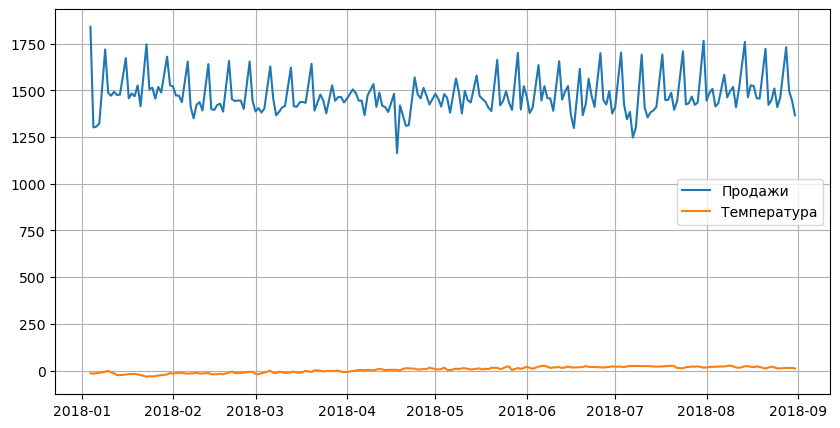

In [80]:
plt.figure(figsize = (10, 5))
plt.plot(df_merged["Дата"], df_merged["Количество продаж"], label = "Продажи")
plt.plot(df_merged["Дата"], df_merged["T"], label = "Температура")
plt.legend()
plt.grid()

plt.show()

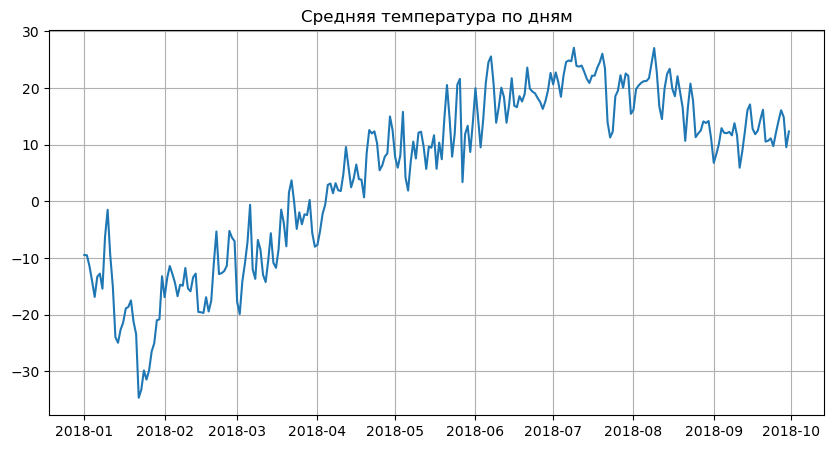

In [81]:
plt.figure(figsize = (10, 5))
plt.plot(weather_daily["Дата"], weather_daily["T"])
plt.grid()
plt.title("Средняя температура по дням")

plt.show()